In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import healpy as hp
import astropy.io.fits as fits
from scipy.stats import pearsonr
from scipy.stats import linregress
from scipy.stats import spearmanr
from scipy.stats import chisquare
from astropy.visualization import ImageNormalize,MinMaxInterval,LogStretch,ManualInterval
from healpy.newvisufunc import projview, newprojplot
from scipy.optimize import curve_fit
from scipy.stats import norm
import astropy.units as u
import math
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import pandas as pd
from mode_coupling_matrix import compute_mode_coupling_matrix_from_mask
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

In [3]:
nside=128

In [4]:
# Final cleaned maps (named 'ELC') from final cleaning fit (Section 3.6)
final_70_map="../ELC_Maps/ELC_70GHz.fits"
final_70=hp.fitsfunc.read_map(final_70_map,field=[0])

final_94_map="../ELC_Maps/ELC_94GHz.fits"
final_94=hp.fitsfunc.read_map(final_94_map,field=[0])

final_100_map="../ELC_Maps/ELC_100GHz.fits"
final_100=hp.fitsfunc.read_map(final_100_map,field=[0])

final_143_map="../ELC_Maps/ELC_143GHz.fits"
final_143=hp.fitsfunc.read_map(final_143_map,field=[0])

In [5]:
# Baseline ΛCDM model from Planck 2018 release
df = pd.read_csv("COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt",delim_whitespace=True, header=None)
com_Dl = df.iloc[1:, 1].astype(float).to_numpy()
ell = np.arange(2, 2 + len(com_Dl))         
lmax= int(ell[-1])

# Convert to Cls
cl_tt = com_Dl / (ell * (ell + 1) / (2.0 * np.pi))

# File starts at ell=2, adjust to start at ell=0 to match the power spectra from maps
cl_tt_full = np.zeros(lmax + 1, dtype=np.float64)
cl_tt_full[2:] = cl_tt

/var/folders/3k/w31y20251nzbdg040fwmv7tc0000gn/T/ipykernel_2633/1954973168.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt",delim_whitespace=True, header=None)


In [6]:
# Import 0.5%, 1%, and 2% masks
mask_005p="../Masks/0.5percent_mask.fits"
mask_005p=hp.fitsfunc.read_map(mask_005p,field=[0])

mask_01p="../Masks/1percent_mask.fits"
mask_01p=hp.fitsfunc.read_map(mask_01p,field=[0])

mask_02p="../Masks/2percent_mask.fits"
mask_02p=hp.fitsfunc.read_map(mask_02p,field=[0])

In [7]:
# Set up dictionary with key names related to mask and map combination to make process smoother

mask_labels = ['005p', '01p', '02p']

map_labels = ['70', '100', '143', '94']

masks = [mask_005p, mask_01p, mask_02p]

maps = [final_143, final_100,final_94,final_70]

results = {}
for i, mask in enumerate(masks):
    for j, map_data in enumerate(maps):
        result_key = f"stdv_mask_{mask_labels[i]}_map_{map_labels[j]}"
        map_debias = (mask * map_data)*1000
        map_debias[np.isnan(map_debias)] = hp.UNSEEN
        results[result_key] = map_debias

In [8]:
# Compute 1 degree fwhm Gaussian winfunc wl_bl in amplitude 
ell=np.arange(384)
beam_sigma_rad = 1.0*np.pi/180.0/np.sqrt(8.*np.log(2.))
wl_bl = np.exp(-0.5*ell*(ell+1)*beam_sigma_rad**2.)

In [9]:
# We use the mode-coupling matrix method to correct for the bias caused by setting pixels to zero 
# (for more detail see Section 3.1 Nofi et al. 2025b)
# 0.5% mask
mask_005p[mask_005p == 0] = hp.UNSEEN
# build the mode-coupling matrix from this mask (see mode_coupling_matrix.py)
M_005 = compute_mode_coupling_matrix_from_mask(mask_005p)
# Need the inverse matrix for the dot product correction
M_005p_inv = np.linalg.inv(M_005)

In [10]:
# 1% mask
mask_01p[mask_01p == 0] = hp.UNSEEN
# build the mode-coupling matrix from this mask (see mode_coupling_matrix.py)
M_01 = compute_mode_coupling_matrix_from_mask(mask_01p)
# Need the inverse matrix for the dot product correction
M_01p_inv = np.linalg.inv(M_01)

In [11]:
# 2% mask
mask_02p[mask_02p == 0] = hp.UNSEEN
# build the mode-coupling matrix from this mask (see mode_coupling_matrix.py)
M_02 = compute_mode_coupling_matrix_from_mask(mask_02p)
# Need the inverse matrix for the dot product correction
M_02p_inv = np.linalg.inv(M_02)

In [12]:
Cl_results_stdv = {} 
Debiased_results = {}  

for key, masked_map in results.items():
    key_parts = key.split('_')
    mask_label = key_parts[2]  # extract the mask part of key
    map_label = key_parts[4]   # extract the map part of key

    Cl_key = f"Cl_{map_label}_{mask_label}"
    # Compute the pseudo-Cl (uncorrected for mode-coupling) from the masked map using hp.anafast
    Cl_results_stdv[Cl_key] = hp.anafast(masked_map, lmax=3 * nside - 1, use_pixel_weights=True)

    M_inv_key = f"M_{mask_label}_inv"
    # Get the inverse mode-coupling matrix for this mask
    M_inv = globals()[M_inv_key]  
    
    test_key = f"test_{map_label}_{mask_label}"
    # Debiased_results stores the Cls corrected for mask-induced mode coupling and for beam and pixel window functions.
    # First dot the inverse mode-coupling matrix by the pseudo-Cl to correct mask bias
    # Then divide by beam window^2 and pixel window^2 to correct for beam and pixel smoothing
    Debiased_results[test_key] = np.dot(M_inv, Cl_results_stdv[Cl_key]) / (((wl_bl)**2) * hp.pixwin(128)**2) 

In [13]:
# Used to convert Cl differences to cosmic variance units
denom = np.sqrt(2.0 / (2.0 * ell + 1.0)) * cl_tt_full[:len(ell)]
# Range for plot (avoid divide by 0s)
valid = (ell >= 2) & (ell <= 30)

(-0.6, 0.6)

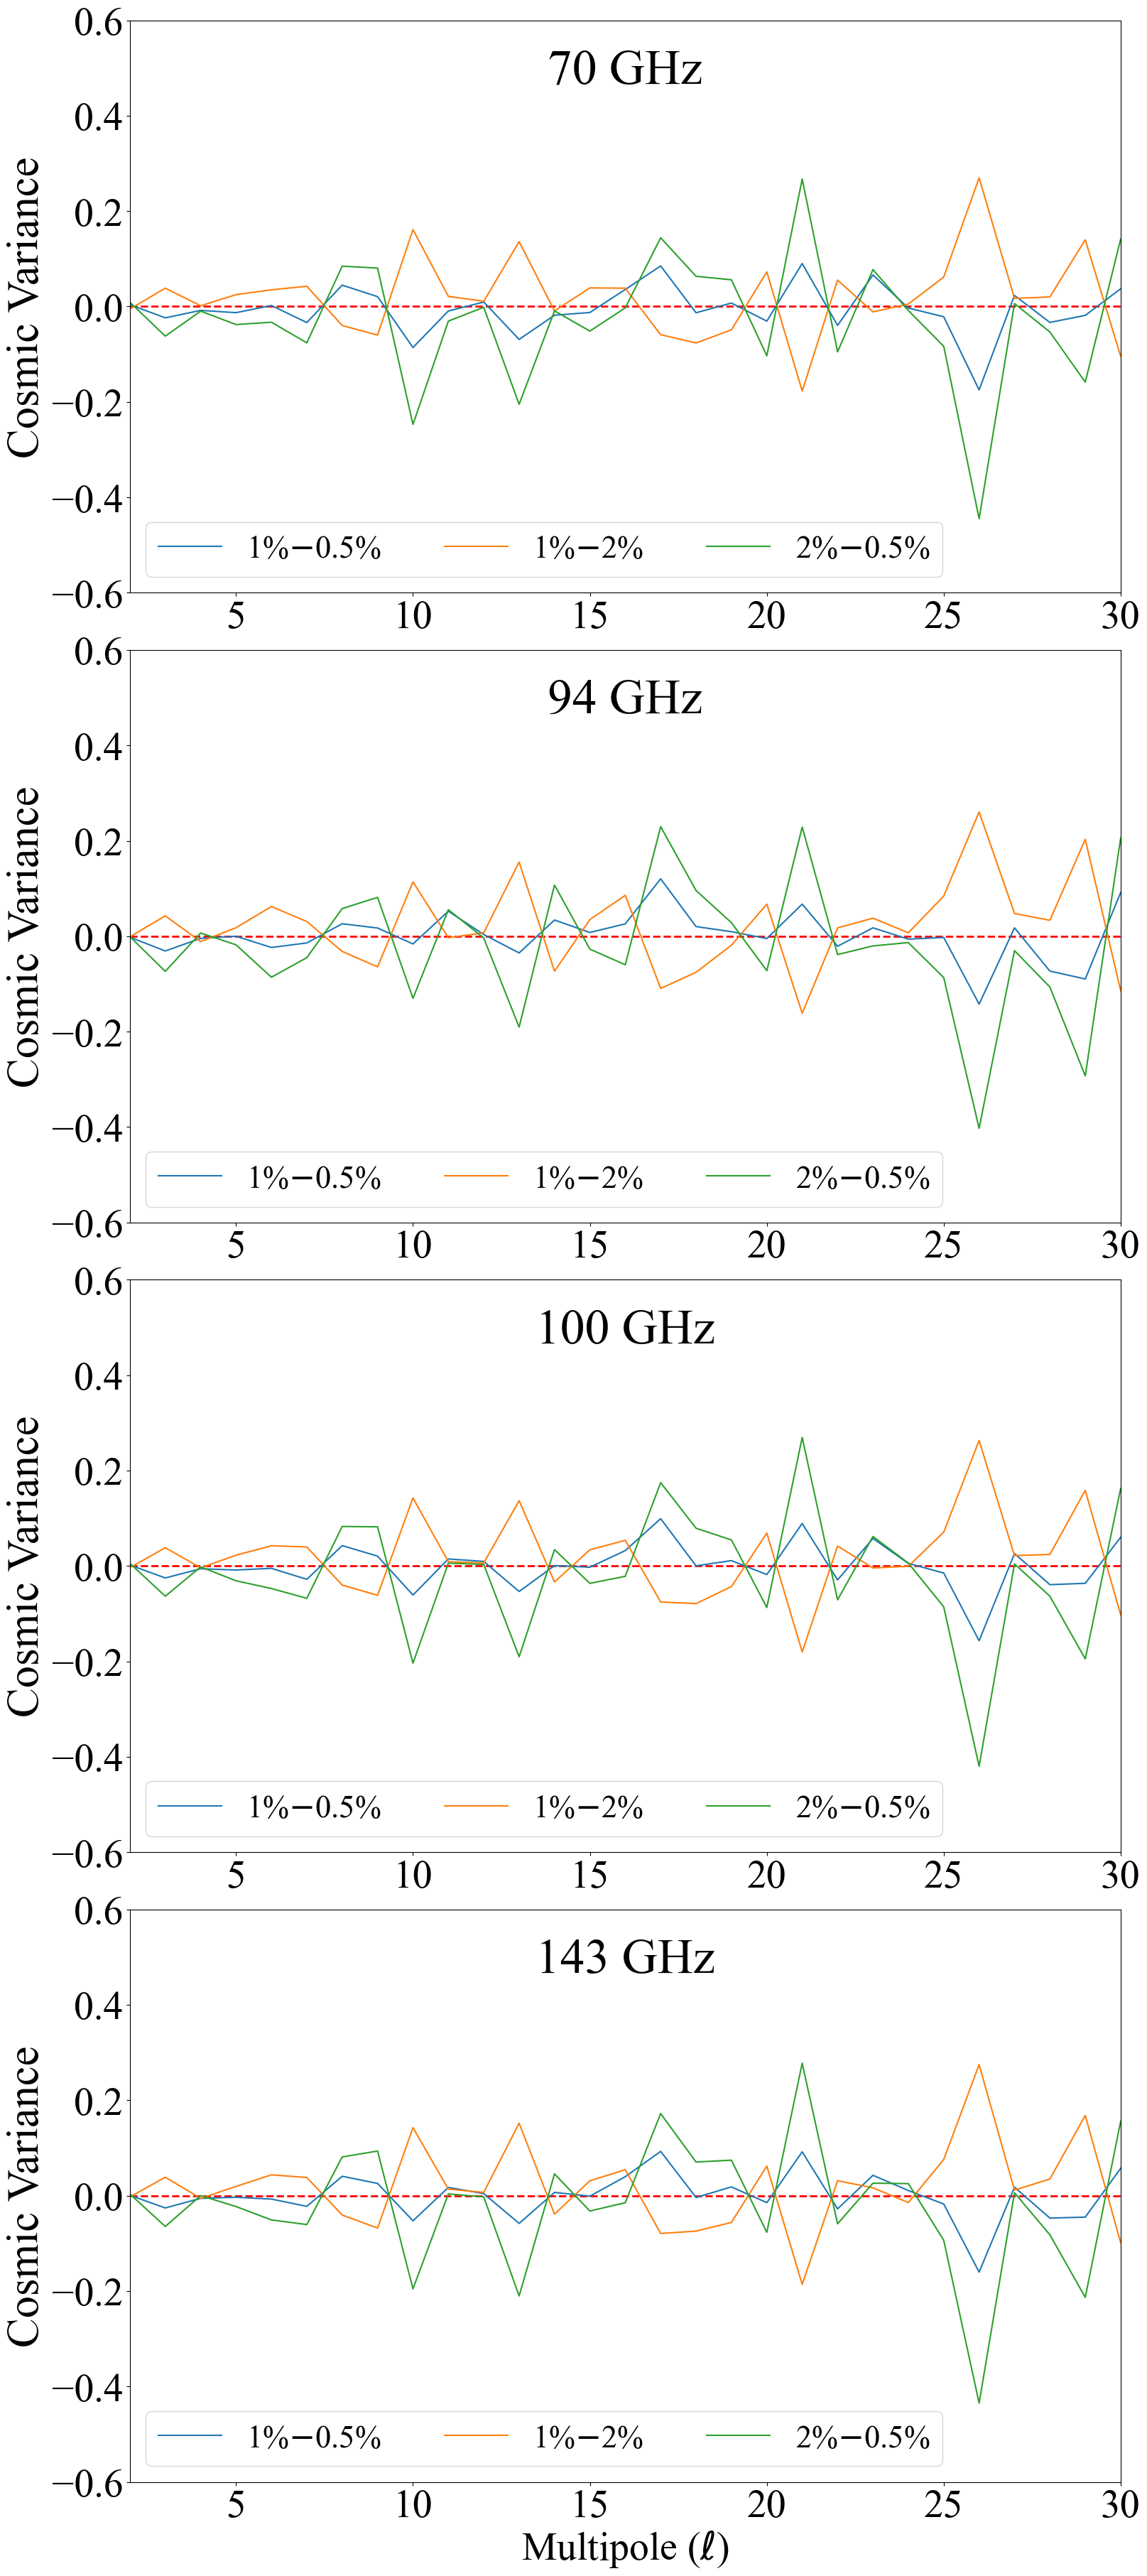

In [ ]:
fig, axe = plt.subplots(4, 1, figsize=(18, 45))
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams.update({'font.size': 40})  # Change the font size to 14


axe[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axe[0].plot(ell[valid], (Debiased_results['test_70_01p'][valid]-Debiased_results['test_70_005p'][valid])/(denom[valid]), label='1%$-$0.5%')
axe[0].plot(ell[valid], (Debiased_results['test_70_01p'][valid]-Debiased_results['test_70_02p'][valid])/(denom[valid]),label='1%$-$2%')
axe[0].plot(ell[valid], (Debiased_results['test_70_02p'][valid]-Debiased_results['test_70_005p'][valid])/(denom[valid]),label='2%$-$0.5%')
axe[0].text(0.5, 0.95, '70 GHz', transform=axe[0].transAxes, fontsize=50, verticalalignment='top', horizontalalignment='center')
axe[0].set_ylabel('Cosmic Variance',fontsize=45)

axe[0].legend(loc='lower left',ncol=3, fontsize=32)
axe[0].set_xlim(2, 30)
axe[0].set_ylim(-0.6,0.6)

axe[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axe[1].plot(ell[valid], (Debiased_results['test_94_01p'][valid]-Debiased_results['test_94_005p'][valid])/(denom[valid]), label='1%$-$0.5%')
axe[1].plot(ell[valid], (Debiased_results['test_94_01p'][valid]-Debiased_results['test_94_02p'][valid])/(denom[valid]),label='1%$-$2%')
axe[1].plot(ell[valid], (Debiased_results['test_94_02p'][valid]-Debiased_results['test_94_005p'][valid])/(denom[valid]),label='2%$-$0.5%')
axe[1].text(0.5, 0.95, '94 GHz', transform=axe[1].transAxes, fontsize=50, verticalalignment='top', horizontalalignment='center')

axe[1].set_ylabel('Cosmic Variance',fontsize=45)
axe[1].legend(loc='lower left',ncol=3, fontsize=32)
axe[1].set_xlim(2, 30)
axe[1].set_ylim(-0.6,0.6)

axe[2].axhline(y=0, color='red', linestyle='--', linewidth=2)
axe[2].plot(ell[valid], (Debiased_results['test_100_01p'][valid]-Debiased_results['test_100_005p'][valid])/(denom[valid]), label='1%$-$0.5%')
axe[2].plot(ell[valid], (Debiased_results['test_100_01p'][valid]-Debiased_results['test_100_02p'][valid])/(denom[valid]),label='1%$-$2%')
axe[2].plot(ell[valid], (Debiased_results['test_100_02p'][valid]-Debiased_results['test_100_005p'][valid])/(denom[valid]),label='2%$-$0.5%')
axe[2].text(0.5, 0.95, '100 GHz', transform=axe[2].transAxes, fontsize=50, verticalalignment='top', horizontalalignment='center')
axe[2].set_ylabel('Cosmic Variance',fontsize=45)

axe[2].legend(loc='lower left',ncol=3, fontsize=32)
axe[2].set_xlim(2, 30)
axe[2].set_ylim(-0.6,0.6)

axe[3].axhline(y=0, color='red', linestyle='--', linewidth=2)
axe[3].plot(ell[valid], (Debiased_results['test_143_01p'][valid]-Debiased_results['test_143_005p'][valid])/(denom[valid]), label='1%$-$0.5%')
axe[3].plot(ell[valid], (Debiased_results['test_143_01p'][valid]-Debiased_results['test_143_02p'][valid])/(denom[valid]),label='1%$-$2%')
axe[3].plot(ell[valid], (Debiased_results['test_143_02p'][valid]-Debiased_results['test_143_005p'][valid])/(denom[valid]),label='2%$-$0.5%')
axe[3].text(0.5, 0.95, '143 GHz', transform=axe[3].transAxes, fontsize=50, verticalalignment='top', horizontalalignment='center')
axe[3].set_xlabel('Multipole ($\ell$)')
axe[3].set_ylabel('Cosmic Variance',fontsize=45)
axe[3].legend(loc='lower left',ncol=3, fontsize=32)
axe[3].set_xlim(2, 30)
axe[3].set_ylim(-0.6,0.6)